In [36]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")
import numpy as np
import seaborn as sns

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [38]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [39]:
print(df.describe())
df.describe(include='object')

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


C:\Users\Hp\AppData\Local\Temp\ipykernel_24400\2472130790.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [40]:
df["Fare"].unique

<bound method Series.unique of 0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64>

{'whiskers': [<matplotlib.lines.Line2D at 0x1dadb153b10>,
 'caps': [<matplotlib.lines.Line2D at 0x1dadb153d90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1dadb1539d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1dadb198050>],
 'fliers': [<matplotlib.lines.Line2D at 0x1dadb198190>],
 'means': []}

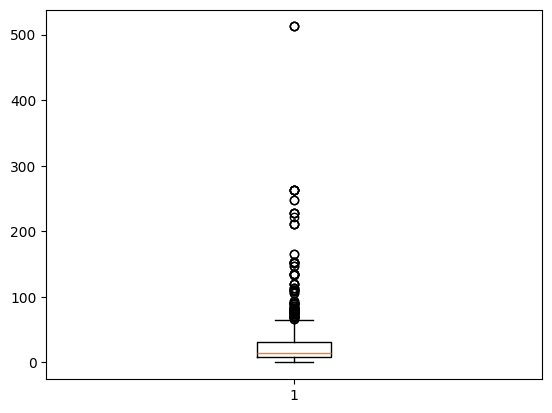

In [41]:
plt.boxplot(df["Fare"])

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Missing Values

In [44]:
df.drop('Cabin',inplace=True,axis=1)

In [45]:
df['Age']= df["Age"].fillna(df["Age"].mean())

In [46]:
s=df[df['Embarked'].isna()]["PassengerId"]
s


61      62
829    830
Name: PassengerId, dtype: int64

In [47]:
df['Embarked'].mode()

0    S
Name: Embarked, dtype: str

In [48]:
df['Embarked']= df["Embarked"].fillna(df['Embarked'].mode()[0])
df[df['PassengerId'].isin(s.values)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,S
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,S


In [49]:
df.drop(['Name','PassengerId'],axis=1,inplace=True)

## Data Visulization

In [67]:
num_con = df.select_dtypes(include='f8').columns
num_discrete = df.select_dtypes(include='i8').columns

num_col = num_con.append(num_discrete)

cat_col = df.select_dtypes(include='str').columns

In [63]:
print(num_con ,'  ',num_discrete,'   ', cat_col )

Index(['Age', 'Fare'], dtype='str')    Index(['Survived', 'Pclass', 'SibSp', 'Parch'], dtype='str')     Index(['Sex', 'Ticket', 'Embarked'], dtype='str')


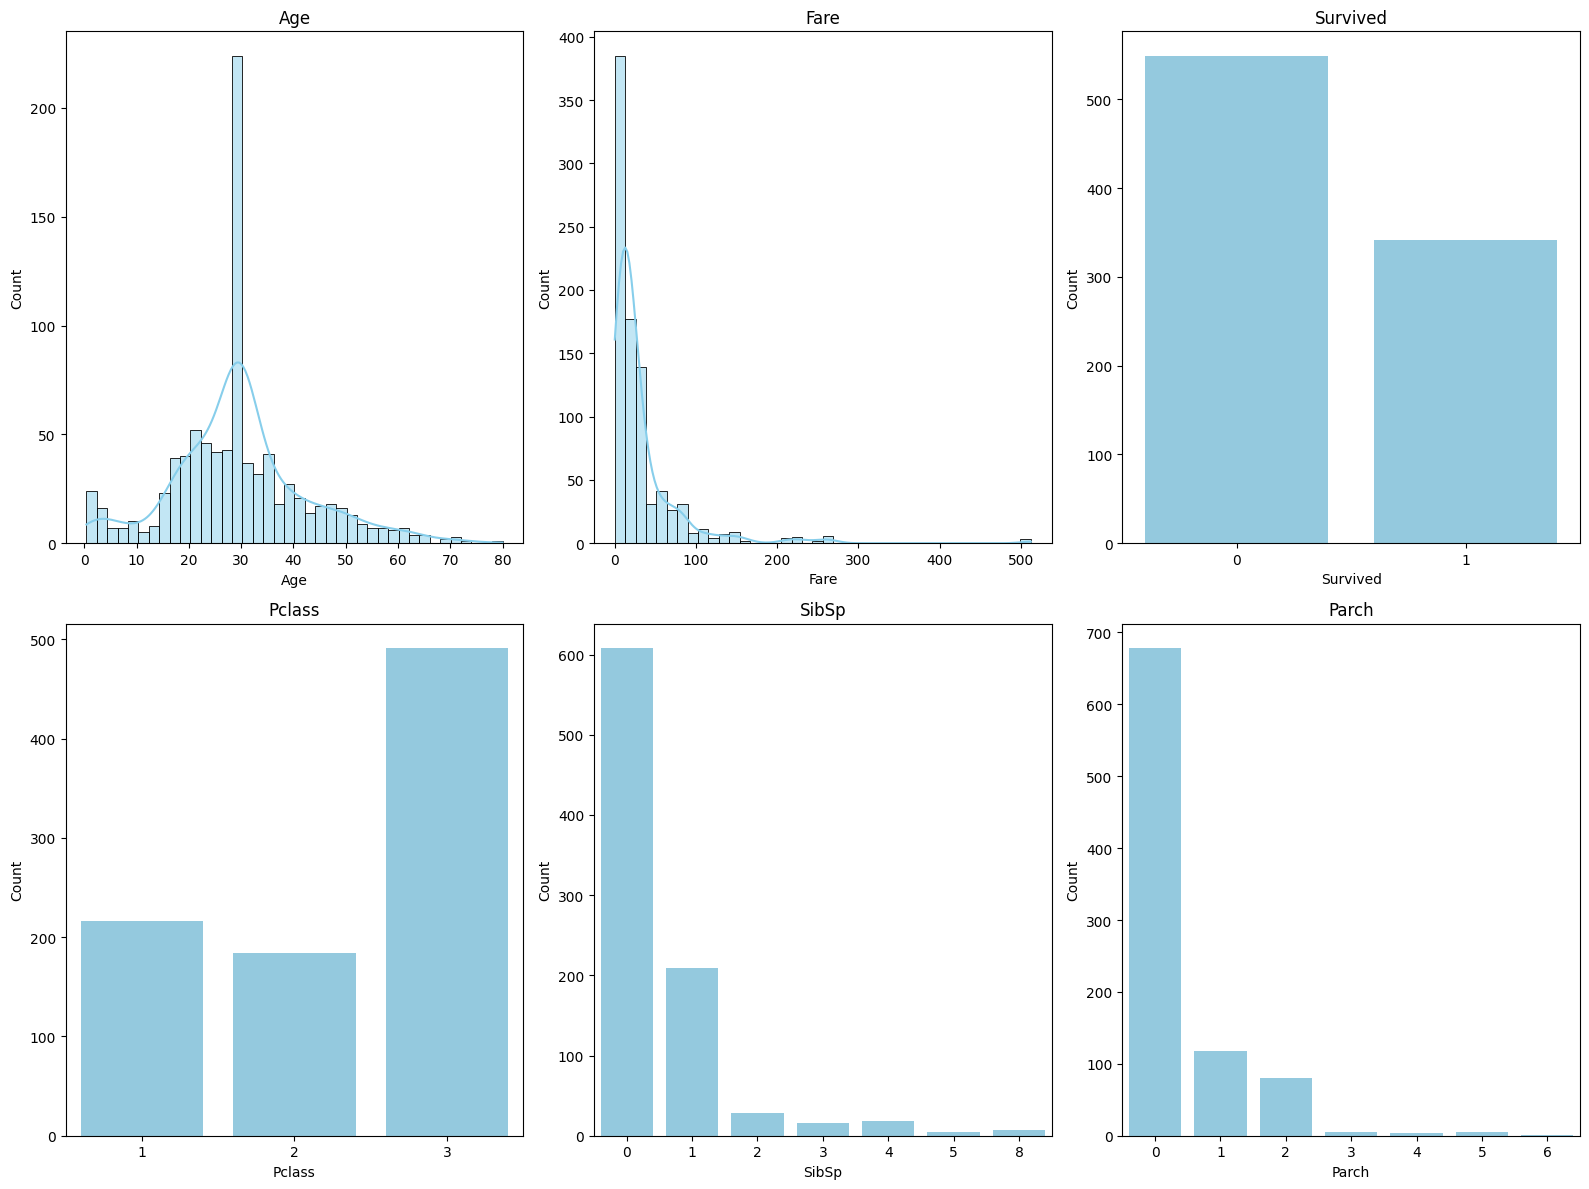

In [69]:
fig, ax = plt.subplots(2,3, figsize=(16, 12))

i = 0
j = 0
for var in num_col :
    if var in num_discrete:
        sns.countplot(x = var, data = df, color = 'skyblue', ax=ax[i,j])
    else:
        sns.histplot(df[var], bins = 40, kde = True, color = 'skyblue', edgecolor = 'black', ax=ax[i,j])
    ax[i,j].set_title(var)
    ax[i,j].set_xlabel(var)
    ax[i,j].set_ylabel('Count')

    if j==2:
        j=0
        i+=1
    else:
        j+=1

plt.tight_layout()
plt.show()

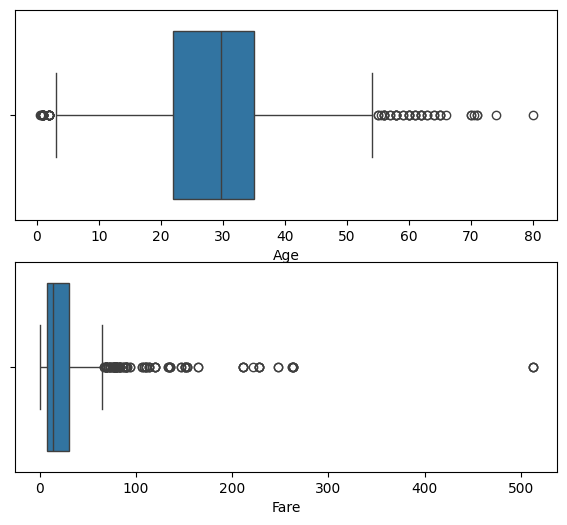

In [85]:
fig, ax = plt.subplots(2,1, figsize=(7, 6))
j=0

for var in num_con:
    sns.boxplot(df,x=var ,ax=ax[j], )
    j=j+1


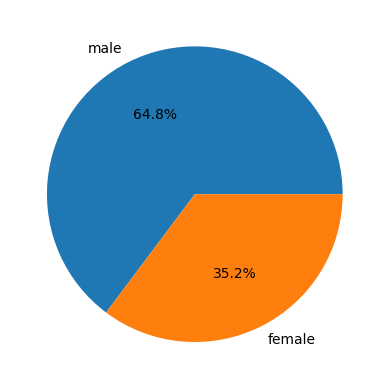

In [88]:
sex_con = df['Sex'].value_counts()
plt.pie(sex_con,labels=sex_con.index,autopct='%1.1f%%')
plt.show()

<Axes: xlabel='Sex', ylabel='count'>

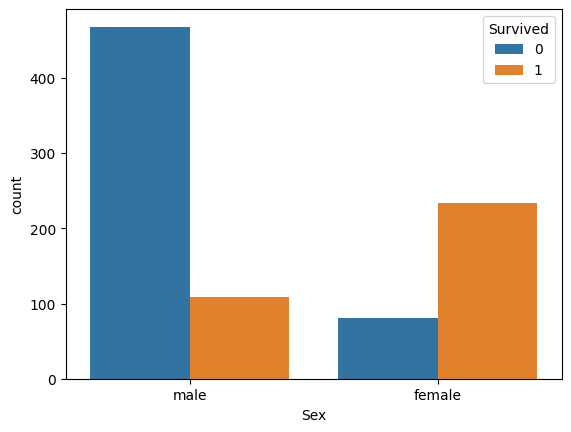

In [94]:
sns.countplot(df,x='Sex',hue='Survived')

<Axes: xlabel='Age', ylabel='Fare'>

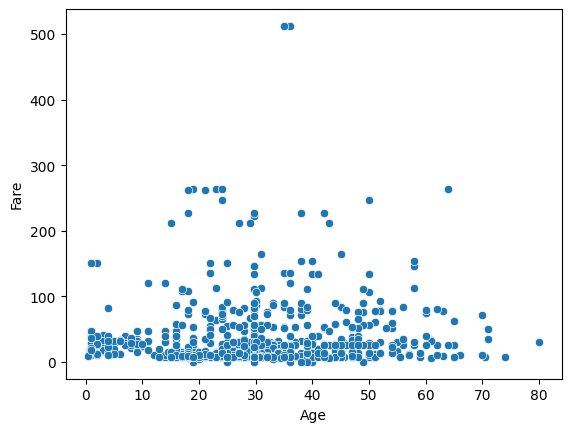

In [95]:
sns.scatterplot(df,x='Age',y='Fare')

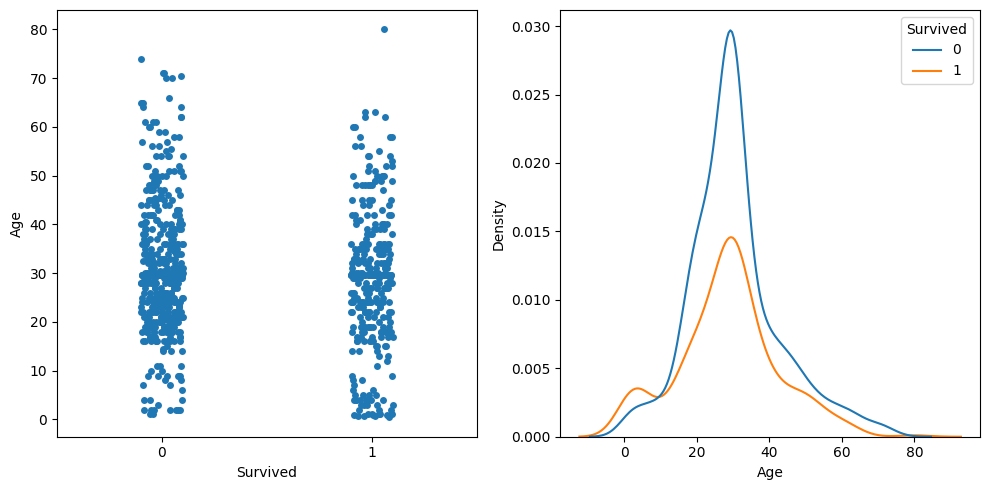

In [112]:
fig , ax = plt.subplots(1,2,figsize=(10,5)) 
sns.stripplot(df,y= 'Age',x='Survived',ax=ax[0] )
sns.kdeplot(df,x='Age',hue='Survived',ax=ax[1])
plt.tight_layout()

<Axes: xlabel='Pclass', ylabel='count'>

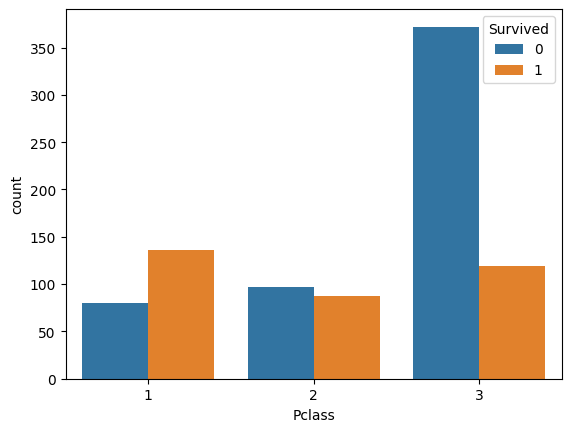

In [119]:
sns.countplot(df,x='Pclass',hue='Survived')

<Axes: >

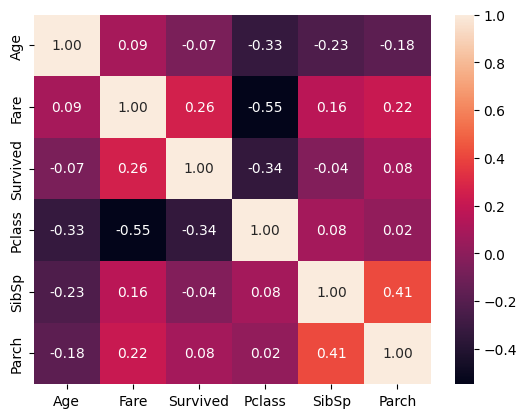

In [113]:
sns.heatmap(df[num_col].corr(),annot=True,fmt='.2f')